In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf 

In [5]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.diagnostic import acorr_ljungbox

In [6]:
bax_data= pd.read_csv('data repository\\BAX.csv',parse_dates =[0], index_col=[0])

In [7]:
bax_data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,66.089996,68.000000,65.820000,67.169998,60.265701,5571300
2018-01-03,67.620003,68.669998,67.239998,68.250000,61.234695,4259900
2018-01-04,68.639999,68.860001,68.010002,68.410004,61.378254,3698000
2018-01-05,68.599998,69.349998,68.300003,69.180000,62.069092,2190000
2018-01-08,69.180000,69.309998,68.699997,69.279999,62.158810,2634900
...,...,...,...,...,...,...
2023-12-22,39.150002,39.459999,38.299999,38.380001,37.781570,4402800
2023-12-26,38.270000,38.830002,38.200001,38.580002,37.978458,2396200
2023-12-27,38.340000,38.759998,38.290001,38.660000,38.057205,2889200


In [8]:
bax_data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

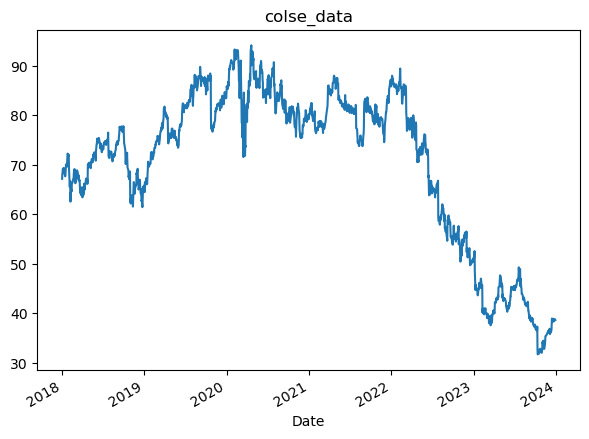

In [9]:
bax_data['Close'].plot(title='colse_data',
                      figsize=(7,5));

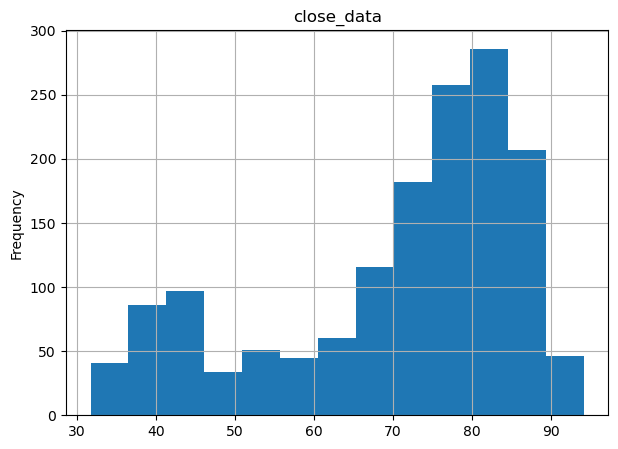

In [10]:
bax_data['Close'].plot(kind='hist',bins=13,figsize=(7,5),grid=True,title='close_data');

In [11]:
bax_data['Close'].describe()

count    1509.000000
mean       70.528648
std        15.821699
min        31.709999
25%        63.849998
50%        75.930000
75%        82.040001
max        94.139999
Name: Close, dtype: float64

In [12]:
bax_data['Close'].var()

250.32617041550102

In [13]:
bax_data['Close'].skew()

-0.9228473944098107

In [14]:
bax_data['Close'].kurt()

-0.3242321653874942

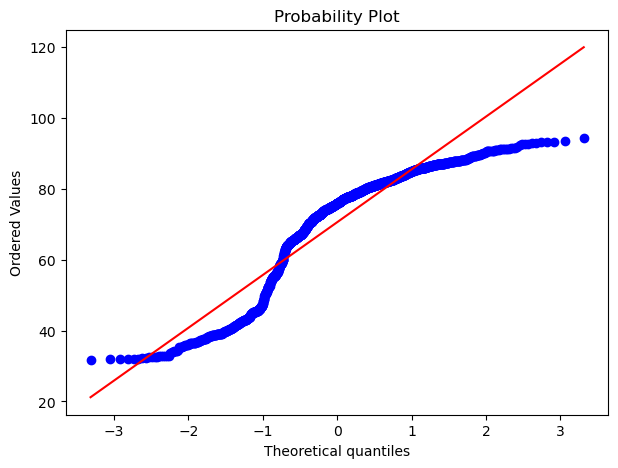

In [15]:
plt.subplots(figsize=(7, 5))
stats.probplot(bax_data['Close'],dist='norm',plot=plt);

In [16]:
stats.shapiro(bax_data['Close'])

ShapiroResult(statistic=0.8815240145631107, pvalue=1.9072062351335328e-32)

In [17]:
stats.jarque_bera(bax_data['Close'])

SignificanceResult(statistic=220.4921737616588, pvalue=1.3204830054456979e-48)

In [18]:
y= bax_data['Close']
x= np.arange(len(y))
x= sm.add_constant(x) 

model = sm.OLS(y,x).fit() 

white_test = het_white(model.resid ,model.model.exog)

In [19]:
white_test

(241.0164244783224,
 4.6126276764892535e-53,
 143.12911549939398,
 1.2347083459106983e-57)

In [20]:
adfuller(bax_data['Close'])

(-0.39276152111649176,
 0.91130034705366,
 17,
 1491,
 {'1%': -3.434743423170358,
  '5%': -2.8634804142964025,
  '10%': -2.567803054306163},
 4785.078768690397)

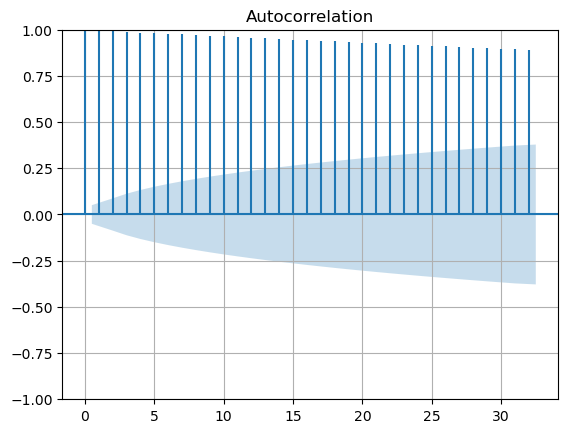

In [21]:
plot_acf(bax_data['Close'],marker='')
plt.grid()

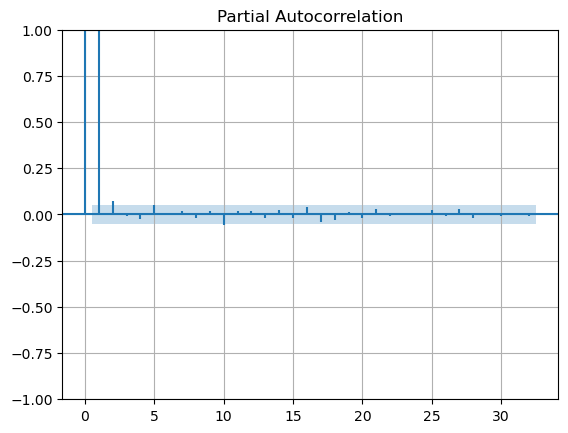

In [22]:
plot_pacf(bax_data['Close'],marker='')
plt.grid()

In [23]:
bax_data['Close_log']= bax_data['Close'].apply(np.log)

In [24]:
bax_data['Close_log_diff']= bax_data['Close_log'].diff()

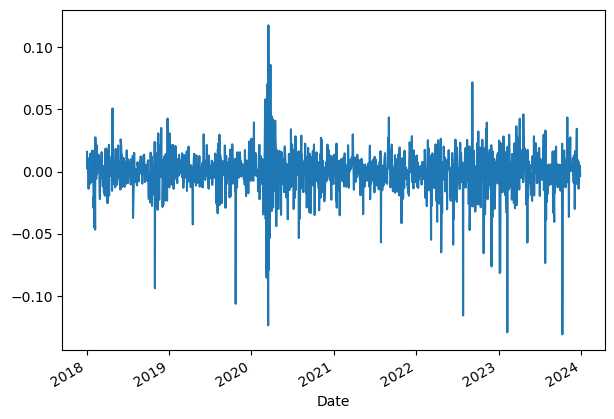

In [25]:
bax_data['Close_log_diff'][1:].plot(figsize=(7,5));

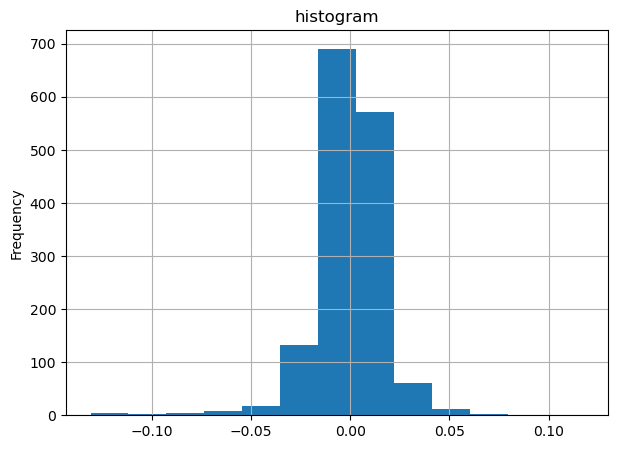

In [26]:
bax_data['Close_log_diff'][1:].plot(kind='hist',bins=13,figsize=(7,5),grid=True)
plt.title('histogram');

In [27]:
bax_data['Close_log_diff'][1:].describe()

count    1508.000000
mean       -0.000366
std         0.017677
min        -0.130932
25%        -0.007746
50%         0.000866
75%         0.008673
max         0.117705
Name: Close_log_diff, dtype: float64

In [28]:
bax_data['Close_log_diff'][1:].var()

0.00031248599031022146

In [29]:
bax_data['Close_log_diff'][1:].skew()

-1.3271995079306065

In [30]:
bax_data['Close_log_diff'][1:].kurt()

11.027823263049536

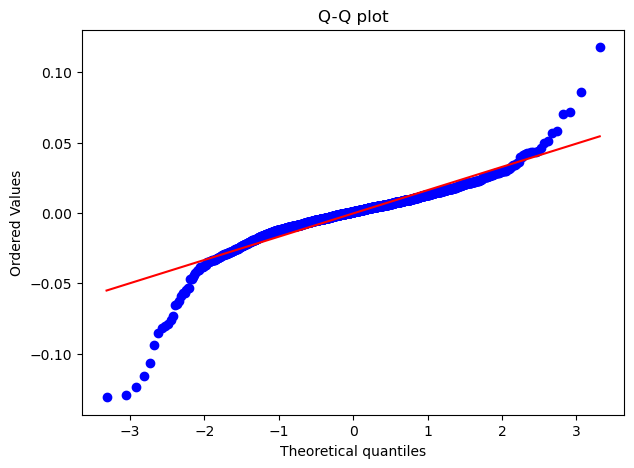

In [31]:
plt.subplots(figsize=(7,5))
stats.probplot(bax_data['Close_log_diff'][1:],dist='norm',plot=plt);
plt.title('Q-Q plot');

In [32]:
stats.shapiro(bax_data['Close_log_diff'][1:])

ShapiroResult(statistic=0.8740668752607899, pvalue=3.102898704550023e-33)

In [33]:
stats.jarque_bera(bax_data['Close_log_diff'][1:])

SignificanceResult(statistic=8027.143532457205, pvalue=0.0)

In [34]:
y2= bax_data['Close_log_diff'][1:]
x2= np.arange(len(y2))
x2=sm.add_constant(x2)

model2= sm.OLS(y2,x2).fit()

white_test2= het_white(model2.resid, model2.model.exog)


In [35]:
white_test2

(3.8216675078559734,
 0.1479569754458951,
 1.9118775596886177,
 0.14816142191015888)

In [36]:
adfuller(bax_data['Close_log_diff'][1:])

(-20.283884429352735,
 0.0,
 3,
 1504,
 {'1%': -3.4347053829922043,
  '5%': -2.863463625572207,
  '10%': -2.5677941141530387},
 -7767.952618467909)

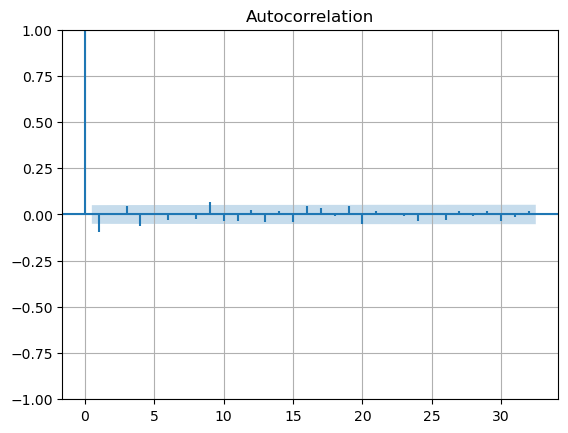

In [37]:
plot_acf(bax_data['Close_log_diff'][1:],marker='');
plt.grid()

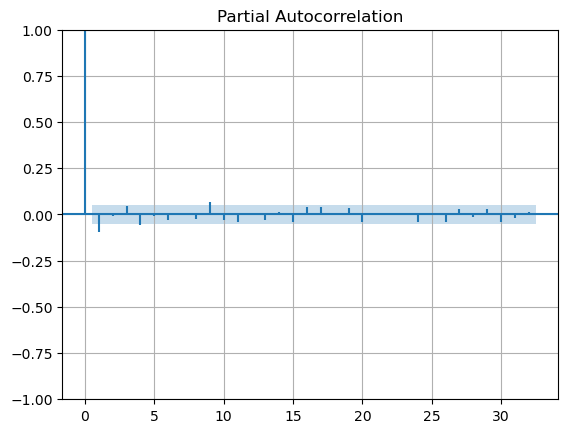

In [38]:
plot_pacf(bax_data['Close_log_diff'][1:],marker='');
plt.grid()

In [41]:
acorr_ljungbox(bax_data['Close_log_diff'][1:],return_df=True,lags=[30])

,lb_stat,lb_pvalue
30,63.816606,0.00031


In [42]:
import pmdarima as pm
auto_arima_model = pm.auto_arima(bax_data['Close_log_diff'][1:], 
                      
                          stepwise=True,   
                          
                          trace=True)      
print(auto_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-7900.071, Time=0.97 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-7888.476, Time=0.18 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-7900.715, Time=0.21 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-7900.635, Time=0.49 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-7889.828, Time=0.11 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-7898.771, Time=0.28 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-7898.742, Time=0.38 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-7896.736, Time=1.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-7901.925, Time=0.07 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-7899.971, Time=0.26 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-7899.948, Time=0.26 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-7901.832, Time=0.23 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-7897.942, Time=0.40 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 4.894 seconds
         

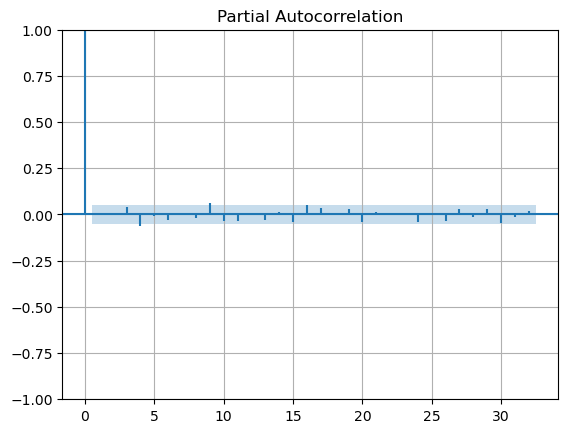

In [43]:
plot_pacf(auto_arima_model.resid(),marker='')
plt.grid()

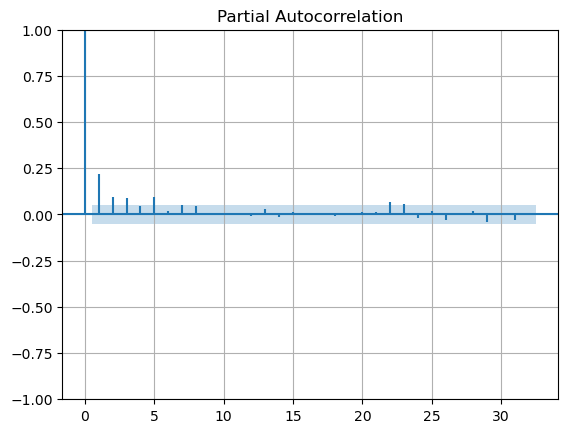

In [44]:
plot_pacf(auto_arima_model.resid()**2,marker='')
plt.grid()

In [45]:
from statsmodels.stats.diagnostic import het_arch

In [46]:
het_arch(auto_arima_model.resid())

(118.79774117421,
 8.872214766997668e-21,
 12.808291169450845,
 1.1370713679291117e-21)

In [47]:
from arch import arch_model

garch_model = arch_model(bax_data['Close_log_diff'][1:],
                        vol='GARCH',
                        mean='AR', 
                        lags=1,
                        p=1 , q=1,
                        rescale=True,
                        dist='studentst'
                        ).fit(update_freq=0)

print(garch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2697.888586884475
            Iterations: 19
            Function evaluations: 150
            Gradient evaluations: 19
                              AR - GARCH Model Results                              
Dep. Variable:               Close_log_diff   R-squared:                       0.002
Mean Model:                              AR   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:               -2697.89
Distribution:      Standardized Student's t   AIC:                           5407.78
Method:                  Maximum Likelihood   BIC:                           5439.68
                                              No. Observations:                 1507
Date:                      Sun, Jul 19 2026   Df Residuals:                     1505
Time:                              21:28:41   Df Model:                            2
                         

In [48]:
egarch_model= arch_model(bax_data['Close_log_diff'][1:],
                         vol='EGARCH',
                         mean='AR',
                         lags=1,
                         dist='studentst',
                         p=1, q=1,
                         rescale=True
                         ).fit(update_freq=0)

print(egarch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2691.423724971849
            Iterations: 19
            Function evaluations: 158
            Gradient evaluations: 19
                             AR - EGARCH Model Results                              
Dep. Variable:               Close_log_diff   R-squared:                       0.001
Mean Model:                              AR   Adj. R-squared:                  0.001
Vol Model:                           EGARCH   Log-Likelihood:               -2691.42
Distribution:      Standardized Student's t   AIC:                           5394.85
Method:                  Maximum Likelihood   BIC:                           5426.75
                                              No. Observations:                 1507
Date:                      Sun, Jul 19 2026   Df Residuals:                     1505
Time:                              21:28:41   Df Model:                            2
                         

In [49]:
tgarch_model= arch_model(bax_data['Close_log_diff'][1:],
                        vol='GARCH',
                        mean='AR',
                        lags=1,
                        dist='studentst',
                        p=1, q=1, o=1,
                        power=1.0,
                        rescale=True
                        ).fit(update_freq=0)

print(tgarch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2687.5875676293726
            Iterations: 21
            Function evaluations: 190
            Gradient evaluations: 21
                           AR - TARCH/ZARCH Model Results                           
Dep. Variable:               Close_log_diff   R-squared:                       0.001
Mean Model:                              AR   Adj. R-squared:                  0.001
Vol Model:                      TARCH/ZARCH   Log-Likelihood:               -2687.59
Distribution:      Standardized Student's t   AIC:                           5389.18
Method:                  Maximum Likelihood   BIC:                           5426.40
                                              No. Observations:                 1507
Date:                      Sun, Jul 19 2026   Df Residuals:                     1505
Time:                              21:28:41   Df Model:                            2
                        

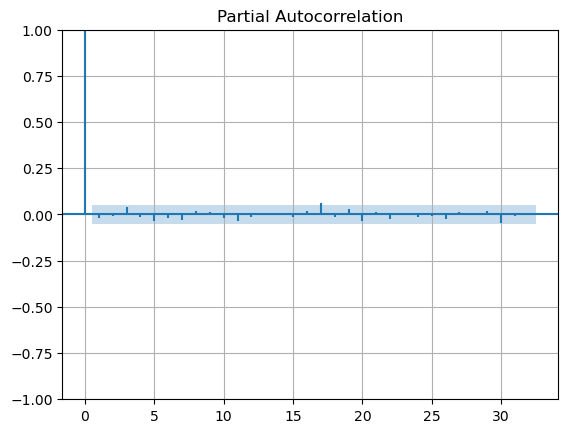

In [50]:
plot_pacf(garch_model.std_resid[1:], marker='')
plt.grid()

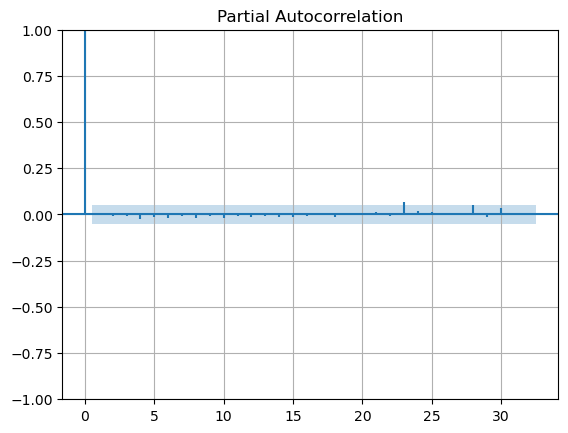

In [51]:
plot_pacf(garch_model.std_resid[1:]**2, marker='')
plt.grid()

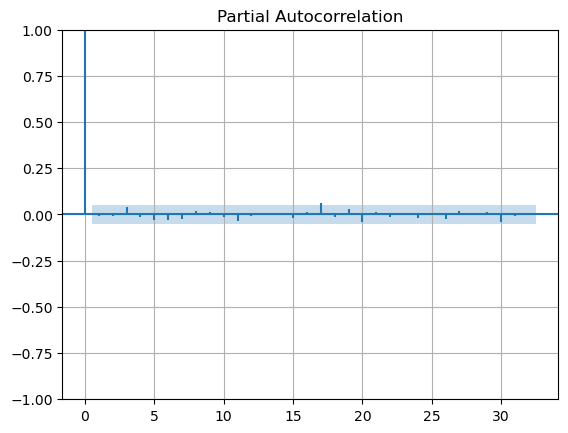

In [52]:
plot_pacf(egarch_model.std_resid[1:], marker='')
plt.grid()

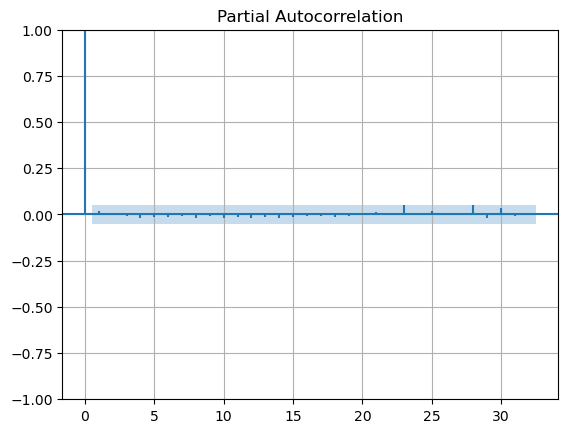

In [53]:
plot_pacf(egarch_model.std_resid[1:]**2, marker='')
plt.grid()

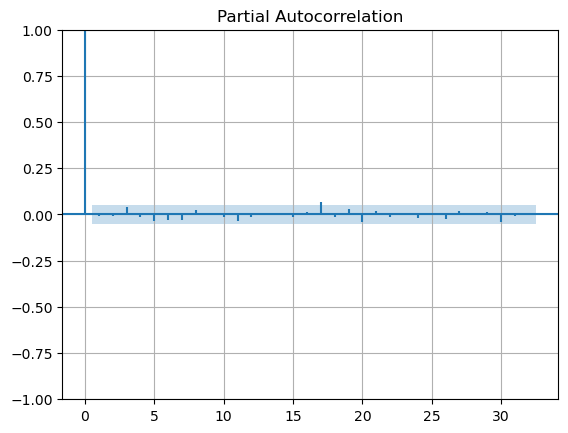

In [54]:
plot_pacf(tgarch_model.std_resid[1:], marker='')
plt.grid()

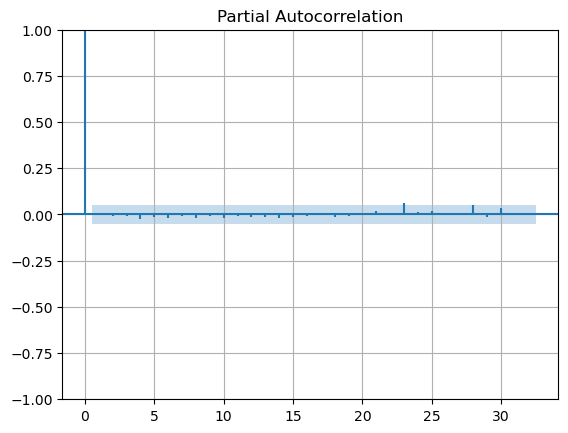

In [55]:
plot_pacf(tgarch_model.std_resid[1:]**2, marker='')
plt.grid()

In [97]:
acorr_ljungbox(egarch_model.std_resid[1:],return_df=True,lags=10)

,lb_stat,lb_pvalue
1,0.106545,0.744113
2,0.158147,0.923972
3,2.682414,0.443224
4,3.068638,0.546405
5,4.661625,0.458554
6,5.595647,0.469973
7,6.743044,0.456115
8,7.324635,0.502046
9,7.532551,0.581850
10,7.828246,0.645609


In [96]:
acorr_ljungbox(tgarch_model.std_resid[1:]**2,return_df=True,lags=10)

,lb_stat,lb_pvalue
1,0.113266,0.736456
2,0.195461,0.906893
3,0.363272,0.947721
4,1.129569,0.889553
5,1.531622,0.909392
6,1.967059,0.922703
7,2.099256,0.954143
8,2.488076,0.962285
9,2.583386,0.978556
10,3.025379,0.980820


In [86]:
het_arch(egarch_model.std_resid[1:])

(2.9919148802832725,
 0.9816136925351432,
 0.2975877812431519,
 0.9818700309119014)